### Importar librerias

In [2]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [3]:
path = '../data/dataset.csv'
df = pd.read_csv(path, header=0)
# print(df.info())

### Celda 1 — Valores nulos
cuenta cuántos valores faltantes hay por columna y los muestra ordenados de mayor a menor porcentaje. Solo aparecen las columnas que sí tienen nulos, para no llenar la pantalla de ceros.

In [4]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Nulos': nulls,
    '% del total': nulls_pct
}).query('Nulos > 0').sort_values('% del total', ascending=False)

print(f"Total de columnas con nulos: {len(null_df)}")
print(null_df)

Total de columnas con nulos: 5
                              Nulos  % del total
average.first.period          99534        69.45
dropped.subject.first.period  99534        69.45
failed.subject.first.period   99534        69.45
admission.rubric              33489        23.37
admission.test                 2177         1.52


Como se puede ver en celda pasada, hay algunas columnas que faltan.
- average.first.period, failed.subject.first.period, dropped.subject.first.period → Estas tres variables solo están disponibles para las generaciones AD19 y AD20 (el modelo TEC21). Para las generaciones anteriores AD14–AD18 simplemente no existe ese dato.
- admission.rubric → Esta variable es una puntuación generada a partir del perfil del estudiante, donde 50 es sobresaliente y 0 es promedio. El paper no explica explícitamente por qué falta en casi un cuarto de los registros.
- admission.test → Existen dos escalas de puntuación dependiendo de cómo se aplicó el examen: la PAA (presencial, rango 400–1600) y la PAL (en línea, rango 0–100), esta última implementada como consecuencia del cierre por COVID-19. Además, para estudiantes provenientes del propio Tec de Monterrey, el campo se marca como "Does not apply" porque no tomaron examen de admisión externo. El pequeño 1.52% restante son probablemente casos donde no hay registro del examen por razones administrativas.

### Celda 2 — Desbalance de clases
mira cuántos estudiantes tienen retention = 1 (se quedaron) vs retention = 0 (desertaron) y calcula el porcentaje de cada grupo. Si uno de los dos tiene mucho menos del 30–35%, hay desbalance y eso hay que atenderlo antes de entrenar cualquier modelo, porque el modelo puede "hacer trampa" prediciendo siempre la clase mayoritaria y lucir con buen accuracy sin aprender nada útil.

In [5]:
counts = df['retention'].value_counts()
pcts   = df['retention'].value_counts(normalize=True) * 100

balance = pd.DataFrame({
    'Etiqueta': ['Desertó (0)', 'Se quedó (1)'],
    'N':        [counts[0], counts[1]],
    '%':        [pcts[0].round(2), pcts[1].round(2)]
})
print(balance.to_string(index=False))

    Etiqueta      N     %
 Desertó (0)  11639  8.12
Se quedó (1) 131687 91.88


### Celda 3 — Heatmap de correlación con retention
calcula la correlación de Pearson entre cada variable numérica y retention. Las barras verdes indican correlación positiva (a más valor de esa variable, más probable que el estudiante se quede) y las rojas negativa (a más valor, más probable que deserte). Variables cerca de 0 tienen poca relación lineal con la variable objetivo. Ojo: esto solo captura relaciones lineales, así que una correlación baja no descarta que la variable sea útil en un modelo más complejo.

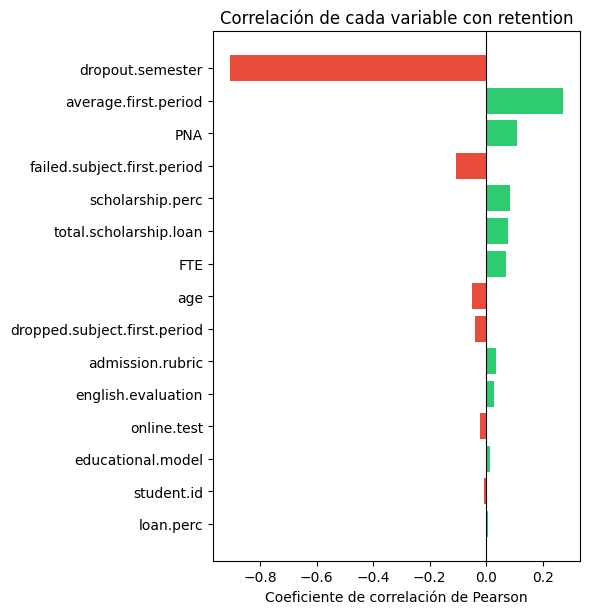

In [6]:
# Solo columnas numéricas
numeric_df = df.select_dtypes(include='number')

# Correlación de todo con 'retention', ordenada por valor absoluto
corr_with_target = (numeric_df
                    .corr()['retention']
                    .drop('retention')
                    .sort_values(key=abs, ascending=False))

plt.figure(figsize=(6, len(corr_with_target) * 0.35 + 1))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada variable con retention')
plt.xlabel('Coeficiente de correlación de Pearson')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()